<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ вакансий из HeadHunter
   

In [5111]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# вставьте сюда параметры подключения из юнита 1. Работа с базой данных из Python 

DBNAME = 'XXXXXXXXXXX'
USER = 'XXXXXXXXXXXX'
PASSWORD = 'XXXXXXXXXXXXXXXXXXXXXXXXX'
HOST = 'X.X.X.X'
PORT = XXXX

In [5113]:
connection = psycopg2.connect(
    dbname=DBNAME,
    user=USER,
    host=HOST,
    password=PASSWORD,
    port=PORT
)

# Юнит 3. Предварительный анализ данных

1. Напишите запрос, который посчитает количество вакансий в нашей базе (вакансии находятся в таблице vacancies). 

In [5114]:
# текст запроса
query_3_1 = f'''
                SELECT COUNT(*) 
                FROM public.vacancies;
             '''

In [5115]:
# результат запроса

df = pd.read_sql_query(query_3_1, connection)
display(df)

C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\735652895.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_3_1, connection)


,count
0,49197


2. Напишите запрос, который посчитает количество работодателей (таблица employers). 

In [5116]:
# текст запроса 

query_3_2 = f'''
                SELECT COUNT(*) 
                FROM public.employers;
             '''

In [5117]:
# результат запроса

df = pd.read_sql_query(query_3_2, connection)
display(df)

C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\4119757511.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_3_2, connection)


,count
0,23501


3. Посчитате с помощью запроса количество регионов (таблица areas).

In [5118]:
# текст запроса

query_3_3 = f'''
                SELECT COUNT(*) 
                FROM public.areas;
             '''

In [5119]:
# результат запроса

df = pd.read_sql_query(query_3_3, connection)
display(df)

C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\1665218811.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_3_3, connection)


,count
0,1362


4. Посчитате с помощью запроса количество сфер деятельности в базе (таблица industries).

In [5120]:
# текст запроса

query_3_4 = f'''
                SELECT COUNT(*) 
                FROM public.industries;
             '''

In [5121]:
# результат запроса

df = pd.read_sql_query(query_3_4, connection)
display(df)

C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\165910779.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_3_4, connection)


,count
0,294


В базе 49197 активных вакансий при 23501 работадателе в 1362 регионах и в 294 сферах деятельности  

***

# Юнит 4. Детальный анализ вакансий

1. Напишите запрос, который позволит узнать, сколько (cnt) вакансий в каждом регионе (area).
Отсортируйте по количеству вакансий в порядке убывания.

In [5122]:
# текст запроса 

query_4_1 = f'''
                SELECT areas.name, COUNT(vacancies.area_id)
                FROM public.areas
                LEFT JOIN public.vacancies
                ON areas.id = vacancies.area_id
                GROUP BY areas.name
                ORDER BY count DESC
                LIMIT 10;
             '''

In [5123]:
# результат запроса

df = pd.read_sql_query(query_4_1, connection)
display(df)

C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\3270675040.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_4_1, connection)


,name,count
0,Москва,5333
1,Санкт-Петербург,2851
2,Минск,2112
3,Новосибирск,2006
4,Алматы,1892
5,Екатеринбург,1698
6,Нижний Новгород,1670
7,Казань,1415
8,Краснодар,1301
9,Самара,1144


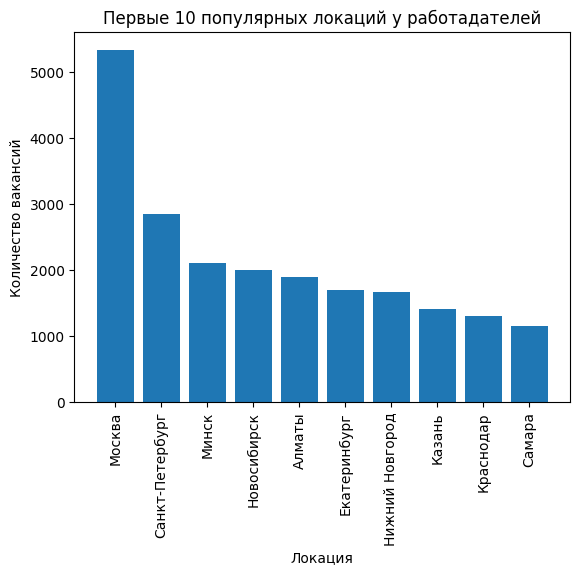

In [5124]:
#Визуализации 
plt.title('Первые 10 популярных локаций у работадателей')
plt.xlabel('Локация')
plt.ylabel('Количество вакансий')
plt.xticks(rotation=90)

plt.bar(
     data=df, 
     x='name',
     height = 'count',
);

2. Напишите запрос, чтобы определить у какого количества вакансий заполнено хотя бы одно из двух полей с зарплатой.

In [5125]:
# текст запроса

query_4_2 = f'''
                SELECT COUNT(*)
                FROM public.vacancies
                WHERE salary_from IS NOT NULL or salary_to IS NOT NULL;
             '''

In [5126]:
# результат запроса

df = pd.read_sql_query(query_4_2, connection)
display(df)

C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\2943097324.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_4_2, connection)


,count
0,24073


3. Найдите средние значения для нижней и верхней границы зарплатной вилки. Округлите значения до целого.

In [5127]:
# текст запроса WHERE salary_from IS NOT NULL or salary_to IS NOT NULL

query_4_3_1 = f'''
                SELECT ROUND(AVG(salary_from), 0)
                FROM public.vacancies;
             '''
             
query_4_3_2 = f'''
                SELECT ROUND(AVG(salary_to),0)
                FROM public.vacancies;
             '''

In [5128]:
# результат запроса

df = pd.read_sql_query(query_4_3_1, connection)
display(df)

df = pd.read_sql_query(query_4_3_2, connection)
display(df)

C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\2151026237.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_4_3_1, connection)


,round
0,71065.0


C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\2151026237.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_4_3_2, connection)


,round
0,110537.0


4. Напишите запрос, который выведет количество вакансий для каждого сочетания типа рабочего графика (schedule) и типа трудоустройства (employment), используемого в вакансиях. Результат отсортируйте по убыванию количества.


In [5129]:
# текст запроса

query_4_4 = f'''
                SELECT schedule, employment, COUNT(*)
                FROM public.vacancies
                GROUP BY schedule, employment
                ORDER BY count DESC;
             '''

In [5130]:
# результат запроса

df = pd.read_sql_query(query_4_4, connection)
display(df)

C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\2712000594.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_4_4, connection)


,schedule,employment,count
0,Полный день,Полная занятость,35367
1,Удаленная работа,Полная занятость,7802
2,Гибкий график,Полная занятость,1593
3,Удаленная работа,Частичная занятость,1312
4,Сменный график,Полная занятость,940
5,Полный день,Стажировка,569
6,Вахтовый метод,Полная занятость,367
7,Полный день,Частичная занятость,347
8,Гибкий график,Частичная занятость,312
9,Полный день,Проектная работа,141


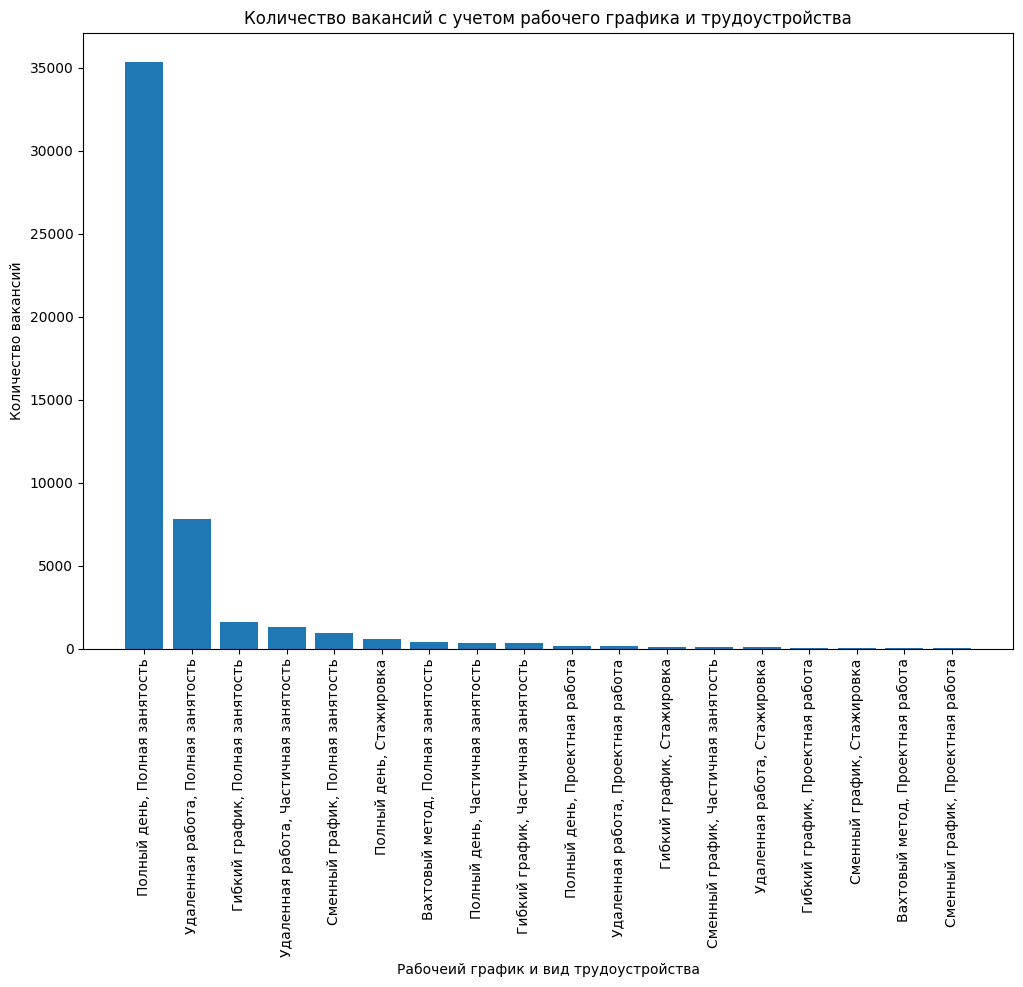

In [5131]:
#Визуализации  

df['all'] = df['schedule'] + ', ' + df['employment']

plt.figure(figsize=(12, 8))
plt.title('Количество вакансий с учетом рабочего графика и трудоустройства')
plt.xlabel('Рабочеий график и вид трудоустройства')
plt.ylabel('Количество вакансий')
plt.xticks(rotation=90)



plt.bar(
     data=df, 
     x='all',
     height = 'count',
);


5. Напишите запрос, выводящий значения поля Требуемый опыт работы (experience) в порядке возрастания количества вакансий, в которых указан данный вариант опыта. 

In [5132]:
# текст запроса

query_4_5 = f'''
                SELECT experience, COUNT(*)
                FROM public.vacancies
                GROUP BY experience
                ORDER BY count ASC;
             '''

In [5133]:
# результат запроса

df = pd.read_sql_query(query_4_5, connection)
display(df)

C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\3886190688.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_4_5, connection)


,experience,count
0,Более 6 лет,1337
1,Нет опыта,7197
2,От 3 до 6 лет,14511
3,От 1 года до 3 лет,26152


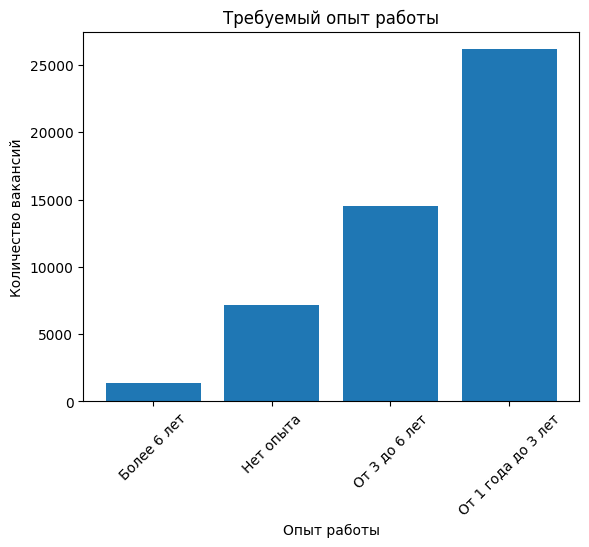

In [5134]:
#Визуализации  

plt.title('Требуемый опыт работы')
plt.xlabel('Опыт работы')
plt.ylabel('Количество вакансий')
plt.xticks(rotation=45)

plt.bar(
     data=df, 
     x='experience',
     height = 'count',
);

***

Самые распрастраненные локации ожидаемо - Москва и Санк-Петербург. В почти половине вакансий (24073, всего 49197) работадатель указалы хотя бы одно значение границы зарплаты. Нижняя граница средней зарплаты - 71065р, верхняя 110537р. В подавляющим большинстве работадателям необходимы сотрудники на польный рабочий день и полную занятость с опытом работы от 1 ло 3 лет.

# Юнит 5. Анализ работодателей

1. Напишите запрос, который позволит узнать, какие работодатели находятся на первом и пятом месте по количеству вакансий.

In [5135]:
# текст запроса

query_5_1 = f'''
                SELECT employers.name, COUNT(vacancies.employer_id)
                FROM public.employers
                LEFT JOIN public.vacancies
                ON employers.id = vacancies.employer_id
                GROUP BY employers.name
                ORDER BY count DESC
                LIMIT 5;
             '''

In [5136]:
# результат запроса

df = pd.read_sql_query(query_5_1, connection)
display(df)

C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\1098783683.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_5_1, connection)


,name,count
0,Яндекс,1933
1,Ростелеком,491
2,Тинькофф,444
3,СБЕР,428
4,Газпром нефть,331


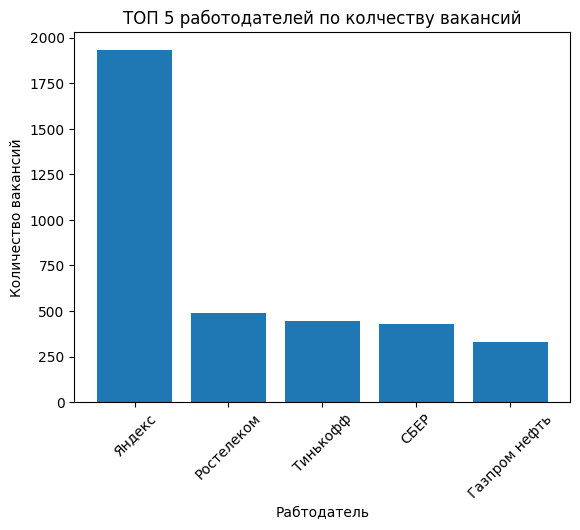

In [5137]:
#Визуализации 

plt.title('ТОП 5 работодателей по колчеству вакансий')
plt.xlabel('Рабтодатель')
plt.ylabel('Количество вакансий')
plt.xticks(rotation=45)

plt.bar(
     data=df, 
     x='name',
     height = 'count',
);

2. Напишите запрос, который для каждого региона выведет количество работодателей и вакансий в нём.
Среди регионов, в которых нет вакансий, найдите тот, в котором наибольшее количество работодателей.


In [5138]:
# текст запроса

query_5_2_1 = f'''
                SELECT areas.name, COUNT(DISTINCT vacancies.employer_id) AS employers1, COUNT(vacancies.id) AS vacancies1
                FROM public.areas
                LEFT JOIN public.vacancies
                ON areas.id = vacancies.area_id
                GROUP BY areas.name
                ORDER BY vacancies1 DESC
                LIMIT 10;
             '''         
      
query_5_2_2 = f'''
                SELECT areas.name, COUNT(*)
                FROM public.areas
                LEFT JOIN public.vacancies
                ON areas.id = vacancies.area_id
                LEFT JOIN public.employers
                ON areas.id = employers.area
                WHERE vacancies.area_id is null
                GROUP BY areas.name
                ORDER BY count DESC
                LIMIT 1;
             '''

In [5139]:
# результат запроса

df = pd.read_sql_query(query_5_2_2, connection)
display(df)

df = pd.read_sql_query(query_5_2_1, connection)
display(df)

C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\4292387001.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_5_2_2, connection)


,name,count
0,Россия,410


C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\4292387001.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_5_2_1, connection)


,name,employers1,vacancies1
0,Москва,2320,5333
1,Санкт-Петербург,1451,2851
2,Минск,851,2112
3,Новосибирск,802,2006
4,Алматы,798,1892
5,Екатеринбург,742,1698
6,Нижний Новгород,657,1670
7,Казань,609,1415
8,Краснодар,578,1301
9,Самара,473,1144


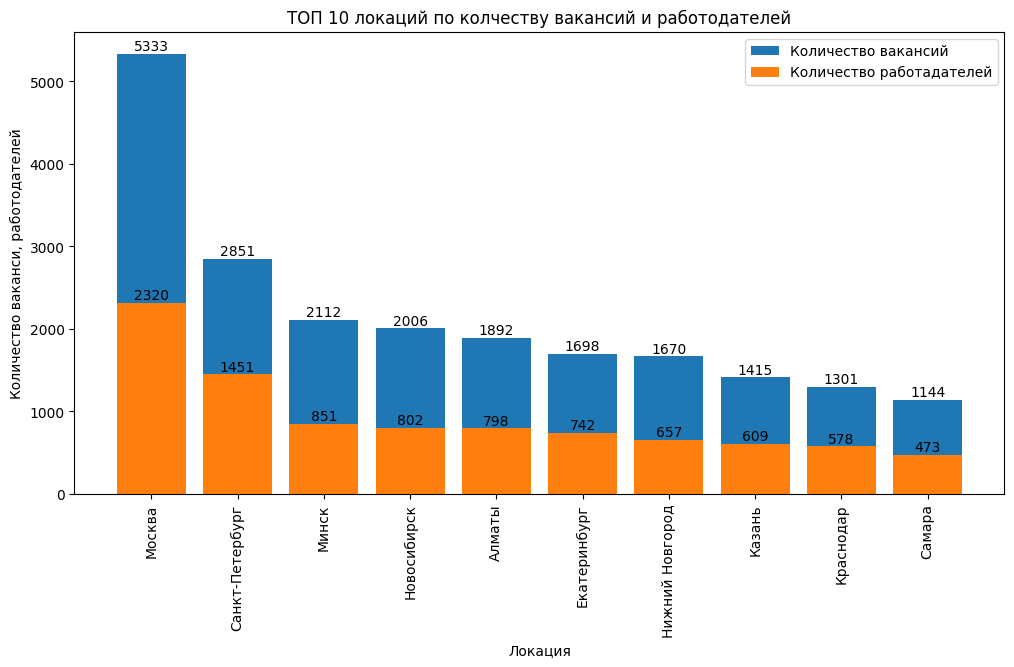

In [5140]:
#Визуализации 

plt.figure(figsize=(12, 6))
plt.title('ТОП 10 локаций по колчеству вакансий и работодателей')
plt.xlabel('Локация')
plt.ylabel('Количество ваканси, работодателей')
plt.xticks(rotation=90)

bars = plt.bar(
     data=df, 
     x='name',
     label='Количество вакансий',
     height = 'vacancies1',
);

for bar in bars:
    height = bar.get_height()
    plt.text(
                bar.get_x() + bar.get_width() / 2,
                height + 1,
                f'{height}',
                ha='center',
                va='bottom',
                fontsize=10
            )

bars_1 = plt.bar(
     data=df, 
     x='name',
     label='Количество работадателей',
     height = 'employers1',
);

for bar in bars_1:
    height = bar.get_height()
    plt.text(
                bar.get_x() + bar.get_width() / 2,
                height + 1,
                f'{height}',
                ha='center',
                va='bottom',
                fontsize=10
            );
    
plt.legend();

3. Для каждого работодателя посчитайте количество регионов, в которых он публикует свои вакансии. Отсортируйте результат по убыванию количества.


In [5141]:
# текст запроса

query_5_3 = f'''
                SELECT employers.name, COUNT(DISTINCT vacancies.area_id) AS employers1
                FROM public.employers
                LEFT JOIN public.vacancies
                ON employers.id = vacancies.employer_id
                GROUP BY employers.name
                ORDER BY employers1 DESC
                LIMIT 10;
             '''

In [5142]:
# результат запроса

df = pd.read_sql_query(query_5_3, connection)
display(df)

C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\4206941721.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_5_3, connection)


,name,employers1
0,Яндекс,181
1,Ростелеком,152
2,Спецремонт,116
3,Поляков Денис Иванович,88
4,ООО ЕФИН,71
5,Совкомбанк,63
6,МТС,55
7,"ЭФКО, Управляющая компания",49
8,Почта России,48
9,КРОН,48


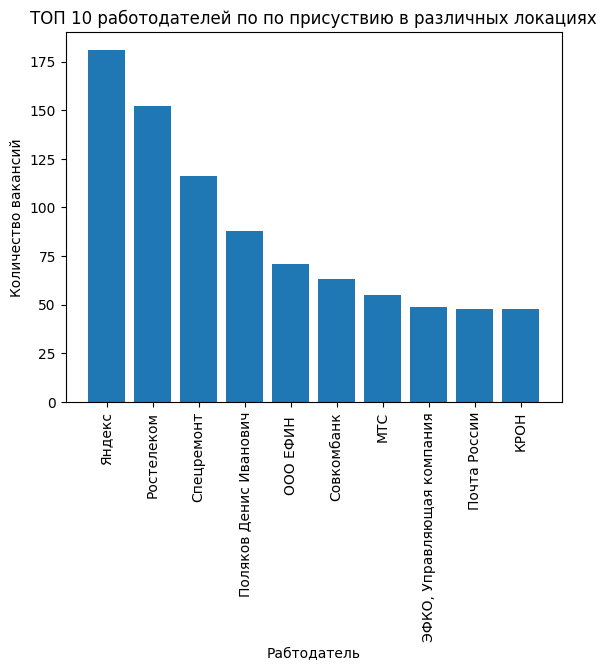

In [5143]:
#Визуализации

plt.title('ТОП 10 работодателей по по присуствию в различных локациях')
plt.xlabel('Рабтодатель')
plt.ylabel('Количество вакансий')
plt.xticks(rotation=90)

plt.bar(
     data=df, 
     x='name',
     height = 'employers1',
);

4. Напишите запрос для подсчёта количества работодателей, у которых не указана сфера деятельности. 

In [5144]:
# текст запроса

query_5_4 = f'''
                SELECT COUNT(id) 
                FROM public.employers
                LEFT JOIN public.employers_industries
                ON employers.id = employers_industries.employer_id
                WHERE employers_industries.industry_id IS NULL
             '''

In [5145]:
# результат запроса

df = pd.read_sql_query(query_5_4, connection)
display(df)

C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\1818094216.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_5_4, connection)


,count
0,8419


5. Напишите запрос, чтобы узнать название компании, находящейся на третьем месте в алфавитном списке (по названию) компаний, у которых указано четыре сферы деятельности. 

In [5146]:
# текст запроса

query_5_5 = f'''
             SELECT employers.name, COUNT(industry_id)
             FROM employers_industries 
             INNER JOIN employers 
             ON employers_industries.employer_id = employers.id
             GROUP BY employers.name
             HAVING COUNT(industry_id) = 4
             ORDER BY employers.name
             LIMIT 3;
             '''
             

In [5147]:
# результат запроса

df = pd.read_sql_query(query_5_5, connection)
display(df)

C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\2454679076.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_5_5, connection)


,name,count
0,101 Интернет,4
1,21vek.by,4
2,2ГИС,4


6. С помощью запроса выясните, у какого количества работодателей в качестве сферы деятельности указана Разработка программного обеспечения.


In [5148]:
# текст запроса

query_5_6 = f'''
             SELECT COUNT(id)
             FROM employers_industries 
             INNER JOIN industries 
             ON employers_industries.industry_id = industries.id
             WHERE name = 'Разработка программного обеспечения';
             '''

In [5149]:
# результат запроса

df = pd.read_sql_query(query_5_6, connection)
display(df)

C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\790804282.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_5_6, connection)


,count
0,3553


7. Для компании «Яндекс» выведите список регионов-миллионников, в которых представлены вакансии компании, вместе с количеством вакансий в этих регионах. Также добавьте строку Total с общим количеством вакансий компании. Результат отсортируйте по возрастанию количества.

Список городов-милионников надо взять [отсюда](https://ru.wikipedia.org/wiki/%D0%93%D0%BE%D1%80%D0%BE%D0%B4%D0%B0-%D0%BC%D0%B8%D0%BB%D0%BB%D0%B8%D0%BE%D0%BD%D0%B5%D1%80%D1%8B_%D0%A0%D0%BE%D1%81%D1%81%D0%B8%D0%B8). 

Если возникнут трудности с этим задание посмотрите материалы модуля  PYTHON-17. Как получать данные из веб-источников и API. 

In [5150]:
# код для получения списка городов-милионников

#Данной темы PYTHON-17. Как получать данные из веб-источников и API. не было на курсе!!!

In [5151]:
# текст запроса

citis_mil = ['Москва', 'Санкт-Петербург', 'Новосибирск', 'Екатеринбург', 'Казань', 'Красноярск', 'Нижний Новгород', 'Челябинск', 'Уфа', 'Самара', 'Ростов-на-Дону', 'Краснодар', 'Омск', 'Воронеж', 'Пермь', 'Волгоград']
# сформантированная строка для запроса 
citis_mil = ", ".join([f"'{i}'" for i in citis_mil])

#print(citis_mil)

query_5_7 = f''' 
             (SELECT areas.name, COUNT(vacancies.id)
             FROM vacancies 
             INNER JOIN areas  
             ON vacancies.area_id = areas.id
             INNER JOIN employers 
             ON employers.id = vacancies.employer_id
             WHERE employers.name = 'Яндекс' and areas.name IN ({citis_mil})
             GROUP BY areas.name
             ORDER BY count ASC)
             UNION ALL
             SELECT 'Total', sum(tmp_table.count) from 
                    (SELECT areas.name, count(vacancies.id)
                    FROM vacancies
                    INNER JOIN areas 
                    ON vacancies.area_id = areas.id
                    INNER JOIN employers 
                    ON employers.id = vacancies.employer_id
                    WHERE employers.name = 'Яндекс' and areas.name IN ({citis_mil})
                    GROUP BY areas.name
                    )tmp_table
             '''

In [5152]:
# результат запроса

       
df = pd.read_sql_query(query_5_7, connection)
display(df)

C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\3009516654.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_5_7, connection)


,name,count
0,Омск,21.0
1,Челябинск,22.0
2,Красноярск,23.0
3,Волгоград,24.0
4,Пермь,25.0
5,Казань,25.0
6,Ростов-на-Дону,25.0
7,Уфа,26.0
8,Самара,26.0
9,Краснодар,30.0


***

Компания с самым большим количеством вакансий - Яндекс. Самое большое количество вакансий и работодателей находиться в Москве. Самое большое представлеия вакансий в локациях так же принадлежить яндексу. 8419 работателей треть от общего количества (23501) предпочли не офишировать сферу деятельности. 3553 работадателей ~15% от общего количестыо работадаьелей занимаются Разработкой программного обеспечения. 

# Юнит 6. Предметный анализ

1. Сколько вакансий имеет отношение к данным?

Считаем, что вакансия имеет отношение к данным, если в её названии содержатся слова 'data' или 'данн'.

*Подсказка: Обратите внимание, что названия вакансий могут быть написаны в любом регистре.* 


In [5153]:
# текст запроса

query_6_1 = f'''
             SELECT COUNT(id)
             FROM vacancies
             WHERE name ILIKE '%data%' OR name ILIKE '%данн%';
             '''

In [5154]:
# результат запроса

df = pd.read_sql_query(query_6_1, connection)
display(df)

C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\3681840826.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_6_1, connection)


,count
0,1771


2. Сколько есть подходящих вакансий для начинающего дата-сайентиста? 
Будем считать вакансиями для дата-сайентистов такие, в названии которых есть хотя бы одно из следующих сочетаний:
* 'data scientist'
* 'data science'
* 'исследователь данных'
* 'ML' (здесь не нужно брать вакансии по HTML)
* 'machine learning'
* 'машинн%обучен%'

** В следующих заданиях мы продолжим работать с вакансиями по этому условию.*

Считаем вакансиями для специалистов уровня Junior следующие:
* в названии есть слово 'junior' *или*
* требуемый опыт — Нет опыта *или*
* тип трудоустройства — Стажировка.
 

In [5155]:
# текст запроса

query_6_2 = f'''
             SELECT COUNT(id)
             FROM vacancies
             WHERE (name ILIKE '%data scientist%' OR 
                    name ILIKE '%data science%' OR
                    name ILIKE '%исследователь данных%' OR
                    (name ILIKE '%ML%' AND name NOT ILIKE '%HTML%') OR
                    name ILIKE '%machine learning%' OR
                    name ILIKE '%машинн%обучен%'
                    ) AND
                    (name ILIKE '%junior%' OR 
                    experience = 'Нет опыта' OR 
                    employment = 'Стажировка');
             '''

In [5156]:
# результат запроса

df = pd.read_sql_query(query_6_2, connection)
display(df)

C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\1677785126.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_6_2, connection)


,count
0,51


3. Сколько есть вакансий для DS, в которых в качестве ключевого навыка указан SQL или postgres?

** Критерии для отнесения вакансии к DS указаны в предыдущем задании.*

In [5157]:
# текст запроса

query_6_3 = f'''
             SELECT COUNT(id)
             FROM vacancies
             WHERE (name ILIKE '%data scientist%' OR 
                    name ILIKE '%data science%' OR
                    name ILIKE '%исследователь данных%' OR
                    (name ILIKE '%ML%' AND name NOT ILIKE '%HTML%') OR
                    name ILIKE '%machine learning%' OR
                    name ILIKE '%машинн%обучен%'
                    ) AND
                    (key_skills ILIKE '%SQL%' OR 
                    key_skills ILIKE '%postgres%');
             '''

In [5158]:
# результат запроса

df = pd.read_sql_query(query_6_3, connection)
display(df)

C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\233722309.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_6_3, connection)


,count
0,229


4. Проверьте, насколько популярен Python в требованиях работодателей к DS.Для этого вычислите количество вакансий, в которых в качестве ключевого навыка указан Python.

** Это можно сделать помощью запроса, аналогичного предыдущему.*

In [5159]:
# текст запроса

query_6_4 = f'''
             SELECT COUNT(id)
             FROM vacancies
             WHERE (name ILIKE '%data scientist%' OR 
                    name ILIKE '%data science%' OR
                    name ILIKE '%исследователь данных%' OR
                    (name ILIKE '%ML%' AND name NOT ILIKE '%HTML%') OR
                    name ILIKE '%machine learning%' OR
                    name ILIKE '%машинн%обучен%'
                    ) AND
                    (key_skills ILIKE '%Python%');
             '''

In [5160]:
# результат запроса

df = pd.read_sql_query(query_6_4, connection)
display(df)

C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\2484689489.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_6_4, connection)


,count
0,357


5. Сколько ключевых навыков в среднем указывают в вакансиях для DS?
Ответ округлите до двух знаков после точки-разделителя.

In [5161]:
# текст запроса

query_6_5 = f'''
             SELECT ROUND(AVG(LENGTH(COALESCE(key_skills, '')) - LENGTH(REPLACE(COALESCE(key_skills, ''), '\t', ''))+1),2)
             FROM vacancies
             WHERE (name ILIKE '%data scientist%' OR 
                    name ILIKE '%data science%' OR
                    name ILIKE '%исследователь данных%' OR
                    (name LIKE '%ML%' AND name NOT ILIKE '%HTML%') OR
                    name ILIKE '%machine learning%' OR
                    name ILIKE '%машинн%обучен%'
                    )  AND (key_skills IS NOT NULL);
             '''


In [5162]:
# результат запроса

df = pd.read_sql_query(query_6_5, connection)
display(df)

C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\3371924086.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_6_5, connection)


,round
0,6.41


6. Напишите запрос, позволяющий вычислить, какую зарплату для DS в **среднем** указывают для каждого типа требуемого опыта (уникальное значение из поля *experience*). 

При решении задачи примите во внимание следующее:
1. Рассматриваем только вакансии, у которых заполнено хотя бы одно из двух полей с зарплатой.
2. Если заполнены оба поля с зарплатой, то считаем зарплату по каждой вакансии как сумму двух полей, делённую на 2. Если заполнено только одно из полей, то его и считаем зарплатой по вакансии.
3. Если в расчётах участвует null, в результате он тоже даст null (посмотрите, что возвращает запрос select 1 + null). Чтобы избежать этой ситуацию, мы воспользуемся функцией [coalesce](https://postgrespro.ru/docs/postgresql/9.5/functions-conditional#functions-coalesce-nvl-ifnull), которая заменит null на значение, которое мы передадим. Например, посмотрите, что возвращает запрос `select 1 + coalesce(null, 0)`

Выясните, на какую зарплату в среднем может рассчитывать дата-сайентист с опытом работы от 3 до 6 лет. Результат округлите до целого числа. 

In [5163]:
# текст запроса (experience = 'От 3 до 6 лет')

query_6_6 = f'''
             SELECT experience, ROUND(AVG(COALESCE((salary_from + salary_to) / 2, salary_from, salary_to)), 0)
             FROM vacancies
             WHERE (name ILIKE '%data scientist%' OR 
                    name ILIKE '%data science%' OR
                    name ILIKE '%исследователь данных%' OR
                    (name LIKE '%ML%' AND name NOT ILIKE '%HTML%') OR
                    name ILIKE '%machine learning%' OR
                    name ILIKE '%машинн%обучен%') AND
                    (key_skills IS NOT NULL)
             GROUP BY experience;
             '''

In [5164]:
# результат запроса

df = pd.read_sql_query(query_6_6, connection)
display(df)

C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\803861920.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_6_6, connection)


,experience,round
0,Более 6 лет,NaN
1,Нет опыта,74643.0
2,От 1 года до 3 лет,146704.0
3,От 3 до 6 лет,243115.0


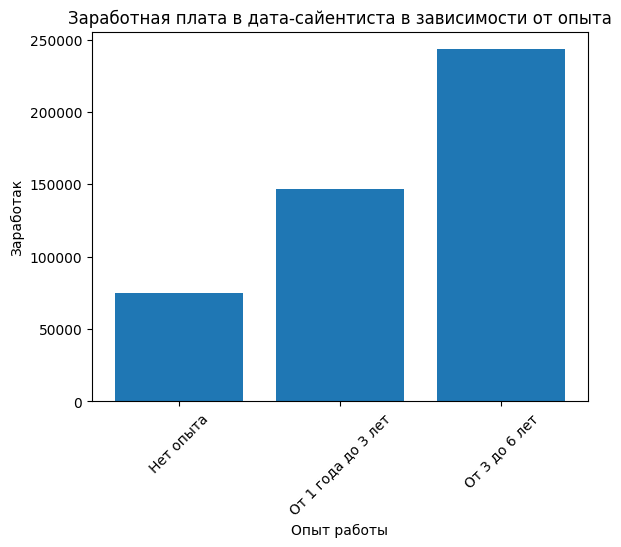

In [5165]:
plt.title('Заработная плата в дата-сайентиста в зависимости от опыта')
plt.xlabel('Опыт работы')
plt.ylabel('Заработак')
plt.xticks(rotation=45)

plt.bar(
     data=df, 
     x='experience',
     height = 'round',
);

***

1771 вакансия относяться к дата-сайентиста это ~ 3.6% от общего количества ваканчий (49197 общее количества). И только 51 вакансия подходить для новичков это ~2.8% от общего количества дата-сайентиста вакансий (1771). Для работателя важнее оказались наваки Python (357), чем SQL или postgres (229). Специалисты дата-сайентиста с  опытом работы могут расчитывать на более высокую зарплату (От 1 года до 3 лет: 146704р. От 3 до 6 лет: 243115р.) чем верхней границы средней зарплаты (Нижняя граница средней зарплаты - 71065р, верхняя 110537р) 

# Общий вывод по проекту

In [5166]:
# подведем итог исследования, обобщите выводы
# здесь можно (это будет плюсом) провести дополнительные исследования данных, сделать прогнозы, продумать варианты продолжения исследования

В базе 49197 активных вакансий при 23501 работадателе в 1362 регионах и в 294 сферах деятельности  

Самые распрастраненные локации ожидаемо - Москва и Санк-Петербург. В почти половине вакансий (24073, всего 49197) работадатель указалы хотя бы одно значение границы зарплаты. Нижняя граница средней зарплаты - 71065р, верхняя 110537р. В подавляющим большинстве работадателям необходимы сотрудники на польный рабочий день и полную занятость с опытом работы от 1 ло 3 лет.

Компания с самым большим количеством вакансий - Яндекс. Самое большое количество вакансий и работодателей находиться в Москве. Самое большое представлеия вакансий в локациях так же принадлежить яндексу. 8419 работателей треть от общего количества (23501) предпочли не офишировать сферу деятельности. 3553 работадателей ~15% от общего количестыо работадаьелей занимаются Разработкой программного обеспечения. 
  
1771 вакансия относяться к дата-сайентиста это ~3.6% от общего количества ваканчий (49197 общее количества). И только 51 вакансия подходить для новичков это ~2.8% от общего количества дата-сайентиста вакансий (1771). Для работателя важнее оказались наваки Python (357), чем SQL или postgres (229). Специалисты дата-сайентиста с  опытом работы могут расчитывать на более высокую зарплату (От 1 года до 3 лет: 146704р. От 3 до 6 лет: 243115р.) чем верхней границы средней зарплаты (Нижняя граница средней зарплаты - 71065р, верхняя 110537р) 

Дата-сайентис одно из высокооплачеваемых направлений в ИТ и занимает порядка ~3.6%. 
Для понимания рынка вакансий и более глубокого понимания Дата-сайентист в нем, необходимо оапределить и выделить другие направления в ИТ и провести такой же анализ как и с дата-сайентистом. 

Группировка и выборка по полю name в безе vacancies дасть не верный результат в разных компаниях одни и теже должности могут называться по разному!!!

Попробую сделать такой же анализ для разработчиков, и дополнить выводы.

Количество ваканчий по WEB разработкам: 695, порядка ~ 1.4% (общее количество вкансий 49197), не попклярное направления в ИТ
Количество ваканчий по WEB разработкам для новичков: 121, порядка ~17.4% (), дружелюбное направления к новичкам
Необходим навак по PHP для вакансии: 406
Необходим навак по JavaScript для вакансии: 392

JavaScript и PHP имеют почти одинаковую популярность у работодателей

Среднее необходимое количество наваков для проффесии: 7.8, в проффессии высокие требования к навакам

Средняя зарплата по проффесии WEB  
Нет опыта	44134.0
От 1 года до 3 лет	75312.0
От 3 до 6 лет	119591.0
Более 6 лет	189642.0

Исходя из анализа по 2 направлениям в ИТ можно сделать следующие выводы:
Дата-сайентис более востребована на рынке ИТ чем ВЕБ программирование.
ВЕБ программирование более дружелюбно в новичкам.
ВЕБ програмирование являеться более навака зависимым направлением
Зарплаты и ВЕБ программироание и Дата-сайентис у опытных спецмалистов выше чем средняя верхняя гараница по всем вакансиям. Также зарплаты в Дата-сайентис чувствительно выше чем в ВЕБ програмирование.

Дата-сайентис более перспективное напраление в ИТ


In [5167]:
query_7_1 = f'''
             SELECT COUNT(id)
             FROM vacancies
             WHERE (name ILIKE '%web%' AND name ILIKE '%Разработ%') OR
                   (name ILIKE '%web%' AND name ILIKE '%Программ%') OR
                   (name ILIKE '%Веб%' AND name ILIKE '%Разработ%') OR
                   (name ILIKE '%Веб%' AND name ILIKE '%Программ%');
                     
             '''
             

In [5168]:
df = pd.read_sql_query(query_7_1, connection);
display(df)

C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\266946528.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_7_1, connection);


,count
0,695


Количество ваканчий по WEB разработкам: 695

In [5169]:
query_7_2 = f'''
             SELECT COUNT(id)
             FROM vacancies
             WHERE ((name ILIKE '%web%' AND name ILIKE '%Разработ%') OR
                   (name ILIKE '%web%' AND name ILIKE '%Программ%') OR
                   (name ILIKE '%Веб%' AND name ILIKE '%Разработ%') OR
                   (name ILIKE '%Веб%' AND name ILIKE '%Программ%')
                    ) AND
                    (name ILIKE '%junior%' OR 
                    name ILIKE '%стаж%' OR
                    experience = 'Нет опыта' OR 
                    employment = 'Стажировка');
             '''

In [5170]:
df = pd.read_sql_query(query_7_2, connection)
display(df)

C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\3686448377.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_7_2, connection)


,count
0,121


Количество ваканчий по WEB разработкам для новичков: 121

In [5171]:
query_7_3 = f'''
             SELECT COUNT(id)
             FROM vacancies
             WHERE ((name ILIKE '%web%' AND name ILIKE '%Разработ%') OR
                   (name ILIKE '%web%' AND name ILIKE '%Программ%') OR
                   (name ILIKE '%Веб%' AND name ILIKE '%Разработ%') OR
                   (name ILIKE '%Веб%' AND name ILIKE '%Программ%')
                    ) AND
                    (key_skills ILIKE '%PHP%');
             '''

In [5172]:
df = pd.read_sql_query(query_7_3, connection)
display(df)

C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\1754570297.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_7_3, connection)


,count
0,406


Необходим навак по PHP для вакансии: 406

In [5173]:
query_7_4 = f'''
             SELECT COUNT(id)
             FROM vacancies
             WHERE ((name ILIKE '%web%' AND name ILIKE '%Разработ%') OR
                   (name ILIKE '%web%' AND name ILIKE '%Программ%') OR
                   (name ILIKE '%Веб%' AND name ILIKE '%Разработ%') OR
                   (name ILIKE '%Веб%' AND name ILIKE '%Программ%')
                    ) AND
                    (key_skills ILIKE '%JavaScript%');
             '''

In [5174]:
df = pd.read_sql_query(query_7_4, connection)
display(df)

C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\1601807650.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_7_4, connection)


,count
0,392


Необходим навак по JavaScript для вакансии: 392

In [5175]:
query_7_5 = f'''
             SELECT ROUND(AVG(LENGTH(COALESCE(key_skills, '')) - LENGTH(REPLACE(COALESCE(key_skills, ''), '\t', ''))+1),2)
             FROM vacancies
             WHERE ((name ILIKE '%web%' AND name ILIKE '%Разработ%') OR
                   (name ILIKE '%web%' AND name ILIKE '%Программ%') OR
                   (name ILIKE '%Веб%' AND name ILIKE '%Разработ%') OR
                   (name ILIKE '%Веб%' AND name ILIKE '%Программ%')
                    )  AND (key_skills IS NOT NULL);
             '''


In [5176]:
df = pd.read_sql_query(query_7_5, connection)
display(df)

C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\1029066562.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_7_5, connection)


,round
0,7.8


Среднее необходимое количество наваков для проффесии: 7.8

In [5177]:
query_7_6 = f'''
             SELECT experience, ROUND(AVG(COALESCE((salary_from + salary_to) / 2, salary_from, salary_to)), 0)
             FROM vacancies
             WHERE ((name ILIKE '%web%' AND name ILIKE '%Разработ%') OR
                   (name ILIKE '%web%' AND name ILIKE '%Программ%') OR
                   (name ILIKE '%Веб%' AND name ILIKE '%Разработ%') OR
                   (name ILIKE '%Веб%' AND name ILIKE '%Программ%')) 
                   AND (key_skills IS NOT NULL)
             GROUP BY experience
             ORDER BY round ASC;
             '''

In [5178]:
df = pd.read_sql_query(query_7_6, connection)
display(df)

C:\Users\Nikolas Shirikin\AppData\Local\Temp\ipykernel_10704\788486511.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query_7_6, connection)


,experience,round
0,Нет опыта,44134.0
1,От 1 года до 3 лет,75312.0
2,От 3 до 6 лет,119591.0
3,Более 6 лет,189642.0


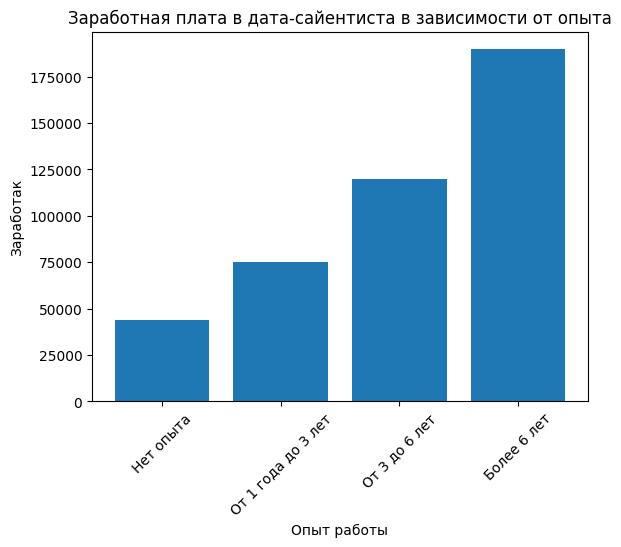

In [5179]:
plt.title('Заработная плата в дата-сайентиста в зависимости от опыта')
plt.xlabel('Опыт работы')
plt.ylabel('Заработак')
plt.xticks(rotation=45)

plt.bar(
     data=df, 
     x='experience',
     height = 'round',
);

Средняя зарплата по проффесии WEB  
Нет опыта	44134.0
От 1 года до 3 лет	75312.0
От 3 до 6 лет	119591.0
Более 6 лет	189642.0

In [5180]:
connection.close()